Retail sales Analysis Project

In [2]:
import pandas as pd
from matplotlib import pyplot as plt
import seaborn as sns

In [3]:
df = pd.read_csv('US Superstore data.csv', encoding= 'latin1')

In [4]:
df.head()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
0,1,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600,2,0.00,41.9136
1,2,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,3,0.00,219.5820
2,3,CA-2016-138688,6/12/2016,6/16/2016,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,...,90036,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200,2,0.00,6.8714
3,4,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,5,0.45,-383.0310
4,5,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680,2,0.20,2.5164


The dataset contains 9,994 rows of retail transactions (2014-2017), including details on Sales, Profit, Discount, Category, and Geography.

# ---Data Cleaning----

In [5]:
df.dtypes

Row ID             int64
Order ID          object
Order Date        object
Ship Date         object
Ship Mode         object
Customer ID       object
Customer Name     object
Segment           object
Country           object
City              object
State             object
Postal Code        int64
Region            object
Product ID        object
Category          object
Sub-Category      object
Product Name      object
Sales            float64
Quantity           int64
Discount         float64
Profit           float64
dtype: object

In [6]:
df['Order Date'] = pd.to_datetime(df['Order Date'])
df['Order_year'] = df['Order Date'].dt.year

df['Order_year'].unique()

array([2016, 2015, 2014, 2017], dtype=int32)

In [7]:
df = df.drop(columns=['Row ID', 'Postal Code'], axis=1)

In [8]:
df.columns

Index(['Order ID', 'Order Date', 'Ship Date', 'Ship Mode', 'Customer ID',
       'Customer Name', 'Segment', 'Country', 'City', 'State', 'Region',
       'Product ID', 'Category', 'Sub-Category', 'Product Name', 'Sales',
       'Quantity', 'Discount', 'Profit', 'Order_year'],
      dtype='object')

In [9]:
df.duplicated().sum()

np.int64(1)

In [10]:
# Sari duplicates including first occurrence
pd.set_option('display.max_columns', None)

duplicates_all = df[df.duplicated(keep=False)]
duplicates_all

,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,State,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit,Order_year
3405,US-2014-150119,2014-04-23,4/27/2014,Standard Class,LB-16795,Laurel Beltran,Home Office,United States,Columbus,Ohio,East,FUR-CH-10002965,Furniture,Chairs,Global Leather Highback Executive Chair with P...,281.372,2,0.3,-12.0588,2014
3406,US-2014-150119,2014-04-23,4/27/2014,Standard Class,LB-16795,Laurel Beltran,Home Office,United States,Columbus,Ohio,East,FUR-CH-10002965,Furniture,Chairs,Global Leather Highback Executive Chair with P...,281.372,2,0.3,-12.0588,2014


During the initial data inspection, I identified duplicate entries (e.g., Order ID: US-2014-150119) that could potentially inflate sales and profit figures.

Observation: Multiple rows contained identical transaction details across all columns.
Action: These duplicates were removed to ensure data integrity.
Impact: This cleaning step ensures that the final analysis is based on unique, verified transactions.

In [11]:
df = df.drop_duplicates()

In [12]:
df.duplicated().sum()

np.int64(0)

In [13]:
df.isnull().sum()

Order ID         0
Order Date       0
Ship Date        0
Ship Mode        0
Customer ID      0
Customer Name    0
Segment          0
Country          0
City             0
State            0
Region           0
Product ID       0
Category         0
Sub-Category     0
Product Name     0
Sales            0
Quantity         0
Discount         0
Profit           0
Order_year       0
dtype: int64

In [14]:
df.describe()

,Order Date,Sales,Quantity,Discount,Profit,Order_year
count,9993,9993.000000,9993.000000,9993.000000,9993.000000,9993.000000
mean,2016-04-30 01:53:33.089162240,229.852846,3.789753,0.156188,28.660971,2015.722406
min,2014-01-03 00:00:00,0.444000,1.000000,0.000000,-6599.978000,2014.000000
25%,2015-05-23 00:00:00,17.280000,2.000000,0.000000,1.731000,2015.000000
50%,2016-06-26 00:00:00,54.480000,3.000000,0.200000,8.671000,2016.000000
75%,2017-05-14 00:00:00,209.940000,5.000000,0.200000,29.364000,2017.000000
max,2017-12-30 00:00:00,22638.480000,14.000000,0.800000,8399.976000,2017.000000
std,NaN,623.276074,2.225149,0.206457,234.271476,1.123479


Summary statistics to understand the distribution of Sales, Profit, and Discounts. Initial observation shows a wide range in Profit, suggesting the presence of significant outliers (losses).

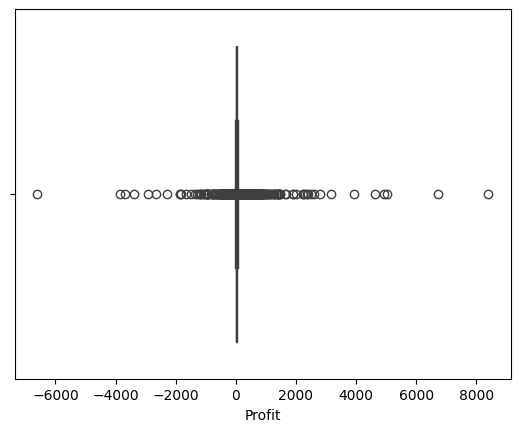

In [15]:
sns.boxplot(x='Profit', data=df)
plt.show()

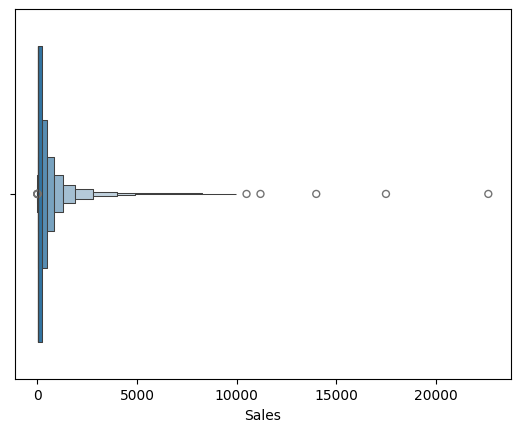

In [16]:
sns.boxenplot(x='Sales', data=df)
plt.show()

Visualizing outliers in Profit and Sales. The Profit boxplot confirms that while most orders are profitable, there are extreme negative outliers (huge losses) that need investigation.

Investigating extreme outliers with losses exceeding $5,000.

In [17]:
df[df['Profit'] < -5000].sort_values(by='Profit', ascending=True)

,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,State,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit,Order_year
7772,CA-2016-108196,2016-11-25,12/2/2016,Standard Class,CS-12505,Cindy Stewart,Consumer,United States,Lancaster,Ohio,East,TEC-MA-10000418,Technology,Machines,Cubify CubeX 3D Printer Double Head Print,4499.985,5,0.7,-6599.978,2016


# Data Visualization

In [18]:
#profit margin

df['Profit_Margin'] = (df['Profit']/df['Sales']) * 100

   Order_year      Profit        Sales  overallProfit
0        2014  49556.0329  483966.1261      10.239566
1        2015  61618.6037  470532.5090      13.095504
2        2016  81795.1743  609205.5980      13.426530
3        2017  93439.2696  733215.2552      12.743771


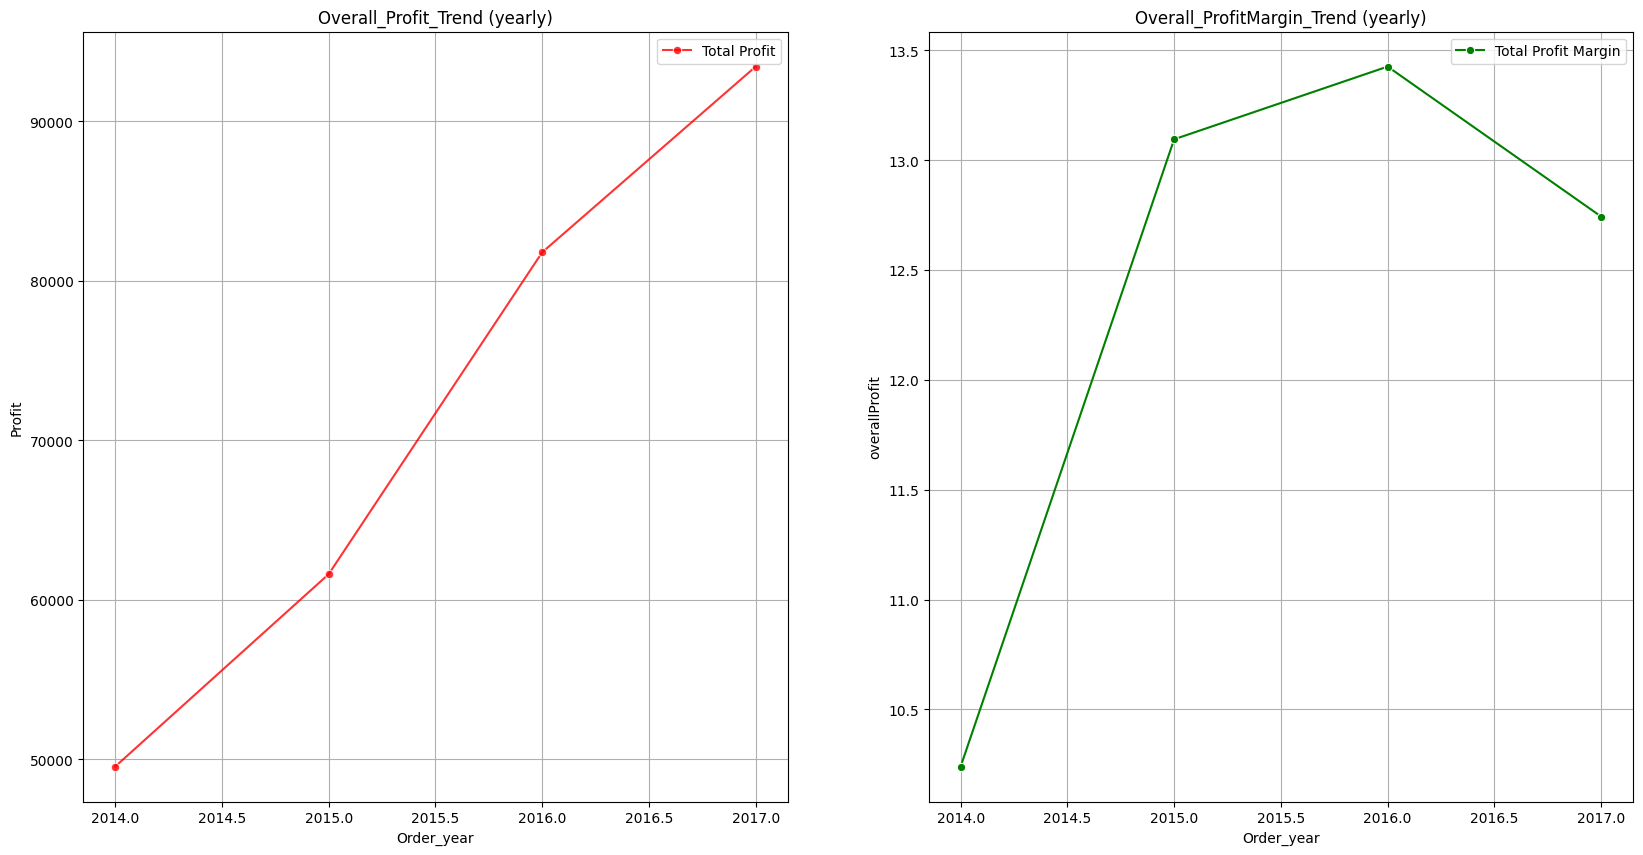

In [19]:
yearlyData = df.groupby('Order_year').agg({
    'Profit' : 'sum',
    'Sales' : 'sum'
}).reset_index()

yearlyData['overallProfit'] = (yearlyData['Profit']/yearlyData['Sales']) * 100

print(yearlyData)

fig, ax = plt.subplots(1,2, figsize=(20, 10))

sns.lineplot(x='Order_year', y='Profit', data=yearlyData, ax=ax[0], alpha=0.8, color='red', label='Total Profit', marker='o')
ax[0].grid()
ax[0].set_title('Overall_Profit_Trend (yearly)')

sns.lineplot(x='Order_year', y='overallProfit', data=yearlyData, ax=ax[1], marker= 'o', color = 'green', label='Total Profit Margin')
ax[1].grid()
ax[1].set_title('Overall_ProfitMargin_Trend (yearly)')

plt.show()

overall the total profit continously grow from year 2014 to 2017 but there is major decline in profit margin in 2017.
In 2014 to 2016 the profit grows from 49K to 81K and the profit margin also grows from 10.2% to 13.4.
But in 2017, although the profit grew to 93K but there is a major decline to  12.7% in 2017.
Even the market has 73K+ sales but they fail to generate profit.

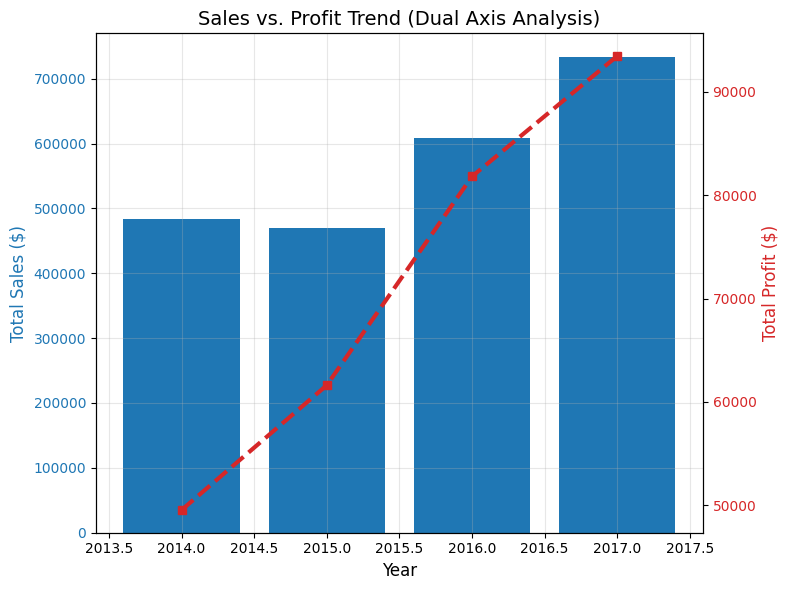

In [20]:
# plot dual axis for provit vs sales trend
fig, ax1 = plt.subplots(figsize=(8, 6))

# --- Pehla Axis (Left Y-axis) Sales ke liye ---
color = 'tab:blue'
ax1.set_xlabel('Year', fontsize=12)
ax1.set_ylabel('Total Sales ($)', color=color, fontsize=12)
ax1.bar(yearlyData['Order_year'], yearlyData['Sales'], color=color, label='Sales')
ax1.tick_params(axis='y', labelcolor=color)
ax1.grid(True, alpha=0.3)

# --- Doosra Axis (Right Y-axis) Profit ke liye ---
ax2 = ax1.twinx()  # Ye line "Magic" hai, jo doosra axis banati hai
color = 'tab:red'
ax2.set_ylabel('Total Profit ($)', color=color, fontsize=12)
ax2.plot(yearlyData['Order_year'], yearlyData['Profit'], color=color, marker='s', linestyle='--', linewidth=3, label='Profit')
ax2.tick_params(axis='y', labelcolor=color)

# 3. Final touches
plt.title('Sales vs. Profit Trend (Dual Axis Analysis)', fontsize=14)
fig.tight_layout() 
plt.savefig("profit vs sales.png")
plt.show()

Sales increased significantly from 2016 to 2017, but profit increased slowly, causing a decline in profit margin.

   Order_year      Profit
0        2014 -31880.7129
1        2015 -32529.3909
2        2016 -37872.9297
3        2017 -53836.1934


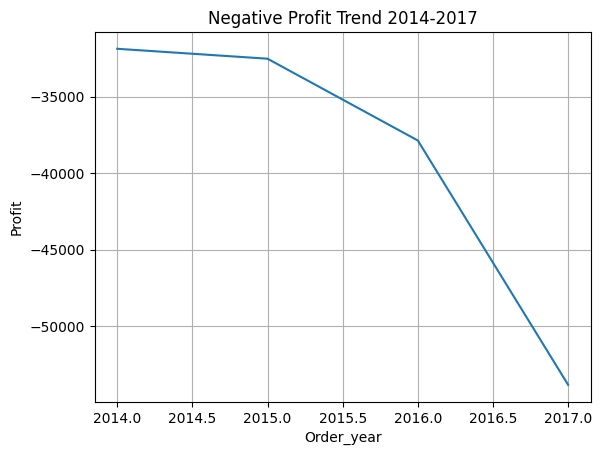

In [21]:
loss_df = df[df['Profit'] < 0]

overall_loss = loss_df.groupby('Order_year')['Profit'].sum().reset_index()

print(overall_loss)

sns.lineplot(x='Order_year', y='Profit', data=overall_loss)
plt.grid()
plt.title('Negative Profit Trend 2014-2017')
plt.show()

The magnitude of negative profit (total losses) increased significantly in 2017 compared to 2016. This suggests that the margin decline is driven by specific high-loss transactions rather than a general drop in sales.

In [22]:
# filtering the 2017 data and loss(negaative) making orders
loss_2017 = df[(df['Order_year'] == 2017) & (df['Profit'] < 0)]

# Category wise loss in 2017
category_loss = loss_2017.groupby('Category')['Profit'].sum().sort_values()

print(category_loss)

Category
Office Supplies   -21742.6334
Furniture         -19291.9999
Technology        -12801.5601
Name: Profit, dtype: float64


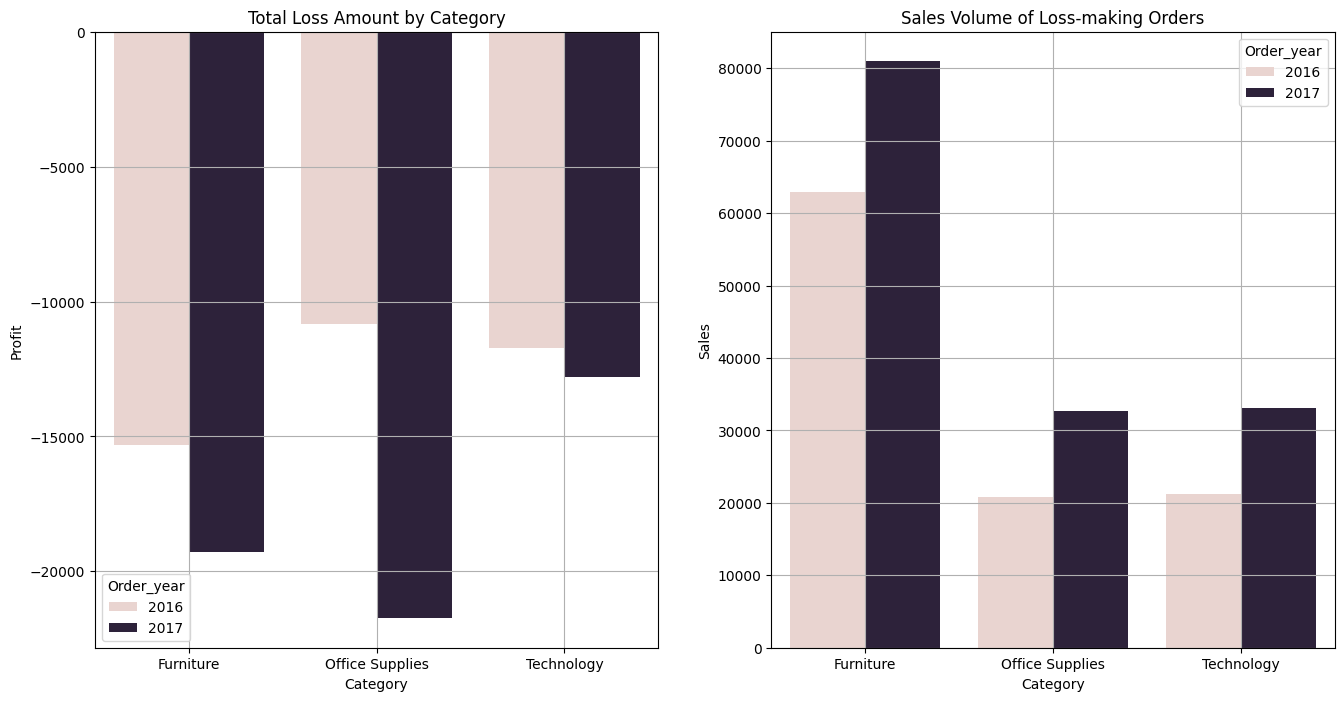

In [34]:
loss1627 = df[(df['Order_year'].isin([2016,2017]) & (df['Profit'] < 0))]

cat_loss = loss1627.groupby(['Order_year','Category']).agg({
    'Profit': 'sum',
    'Sales': 'sum'
}).reset_index()

fig, ax = plt.subplots(1, 2, figsize=(16, 8))

sns.barplot(x='Category', y='Profit', hue='Order_year', data=cat_loss, ax=ax[0])
ax[0].grid()
ax[0].set_title('Total Loss Amount by Category')

sns.barplot(x='Category', y='Sales',  hue='Order_year', data=cat_loss, ax=ax[1])
ax[1].grid()
ax[1].set_title('Sales Volume of Loss-making Orders')

plt.savefig('Segmnetation_Category_wise')
plt.show()

In [24]:
cat_loss

,Order_year,Category,Profit,Sales
0,2016,Furniture,-15318.5445,62972.4245
1,2016,Office Supplies,-10819.2724,20758.1130
2,2016,Technology,-11735.1128,21273.1110
3,2017,Furniture,-19291.9999,81004.5337
4,2017,Office Supplies,-21742.6334,32621.7630
5,2017,Technology,-12801.5601,33051.8100


Office Supplies stands out as the primary concern. In just one year, its losses more than doubled—plunging from -$10.8k to -$21.7k—despite maintaining significant sales volume. This confirms that we are dealing with a systemic issue where we are successfully moving products but doing so at a price that doesn't even cover basic costs.

Similarly, Furniture and Technology also show consistent negative margins. The data proves that our growth in these segments is 'artificial.' We are essentially scaling a deficit—the more we sell under current discount structures, the more financial damage we sustain. This points to a desperate need to overhaul our pricing strategy, specifically in the Central Region.

In [25]:
# slicing the only negative profit category office supplies in 2017
office_loss_2017 = df[(df['Order_year'] == 2017) & 
                       (df['Category'] == 'Office Supplies') & 
                       (df['Profit'] < 0)]

# Region wise breakdown 
region_loss = office_loss_2017.groupby('Region').agg({
    'Profit': 'sum',
    'Sales': 'sum'
}).reset_index()

print("2017 Office Supplies Loss by Region:\n", region_loss)

2017 Office Supplies Loss by Region:
     Region      Profit      Sales
0  Central -13904.1801  11764.126
1     East  -3585.2241  11618.447
2    South  -3363.8229   6224.944
3     West   -889.4063   3014.246


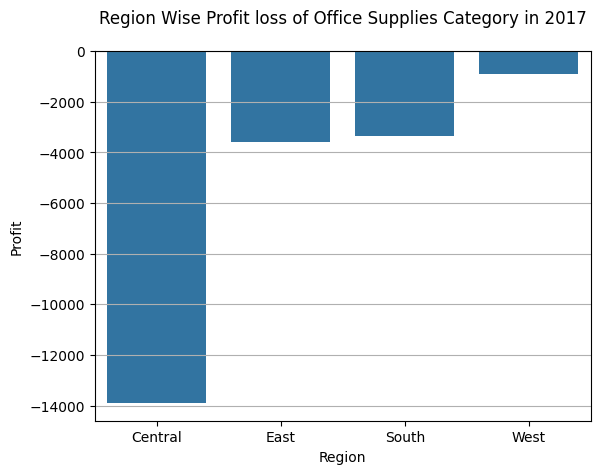

In [39]:
sns.barplot(x='Region', y='Profit', data=region_loss)
plt.grid(axis='y')
plt.title('Region Wise Profit loss of Office Supplies Category in 2017', pad=20)
plt.show()

In [27]:
regionOfficeLoss = df[(df['Order_year'] == 2017) & (df['Region'] == 'Central') & (df['Category'] == 'Office Supplies') & (df['Profit'] < 0)]

check_regionOfficeLoss = regionOfficeLoss.groupby('Sub-Category')['Profit'].sum().reset_index()
check_regionOfficeLoss

,Sub-Category,Profit
0,Appliances,-2637.0186
1,Binders,-10607.4452
2,Storage,-656.9313
3,Supplies,-2.7850


In [36]:
final_check = regionOfficeLoss.groupby('Sub-Category').agg({
    'Profit': 'sum',
    # 'Discount': 'mean',
    'Sales': 'sum'
}).sort_values(by='Profit')

print(final_check)

final_check_vis = final_check.reset_index()


                  Profit     Sales
Sub-Category                      
Binders      -10607.4452  6809.936
Appliances    -2637.0186  1019.814
Storage        -656.9313  3920.104
Supplies         -2.7850    14.272


  Sub-Category      Profit     Sales
0      Binders -10607.4452  6809.936
1   Appliances  -2637.0186  1019.814
2      Storage   -656.9313  3920.104
3     Supplies     -2.7850    14.272


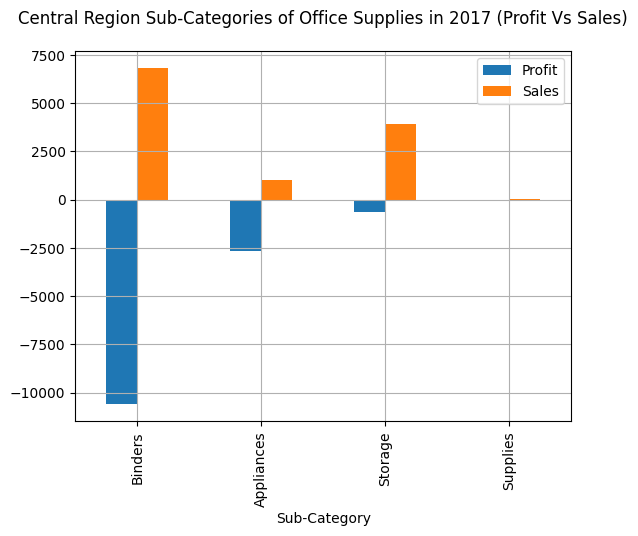

In [37]:
final_check_vis.plot(x='Sub-Category', y=['Profit', 'Sales'], kind='bar')
plt.title('Central Region Sub-Categories of Office Supplies in 2017 (Profit Vs Sales)', pad=20)

print(final_check_vis)
plt.grid()
plt.show()

Root Cause: The data shows that Binders are responsible for the largest share of the loss ($-10.6k$). Notice the Discount average is 0.8 (80%). This confirms that extreme discounting is destroying our value in this sub-category.

In [30]:
Discount_Profit = df[(df['Order_year'] == 2017 ) & (df['Region'] == 'Central')]
Discount_Profit.head()

,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,State,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit,Order_year,Profit_Margin
34,CA-2017-107727,2017-10-19,10/23/2017,Second Class,MA-17560,Matt Abelman,Home Office,United States,Houston,Texas,Central,OFF-PA-10000249,Office Supplies,Paper,Easy-staple paper,29.472,3,0.2,9.9468,2017,33.75
41,CA-2017-120999,2017-09-10,9/15/2017,Standard Class,LC-16930,Linda Cazamias,Corporate,United States,Naperville,Illinois,Central,TEC-PH-10004093,Technology,Phones,Panasonic Kx-TS550,147.168,4,0.2,16.5564,2017,11.25
71,CA-2017-114440,2017-09-14,9/17/2017,Second Class,TB-21520,Tracy Blumstein,Consumer,United States,Jackson,Michigan,Central,OFF-PA-10004675,Office Supplies,Paper,Telephone Message Books with Fax/Mobile Sectio...,19.050,3,0.0,8.7630,2017,46.00
75,US-2017-118038,2017-12-09,12/11/2017,First Class,KB-16600,Ken Brennan,Corporate,United States,Houston,Texas,Central,OFF-BI-10004182,Office Supplies,Binders,Economy Binders,1.248,3,0.8,-1.9344,2017,-155.00
76,US-2017-118038,2017-12-09,12/11/2017,First Class,KB-16600,Ken Brennan,Corporate,United States,Houston,Texas,Central,FUR-FU-10000260,Furniture,Furnishings,"6"" Cubicle Wall Clock, Black",9.708,3,0.6,-5.8248,2017,-60.00


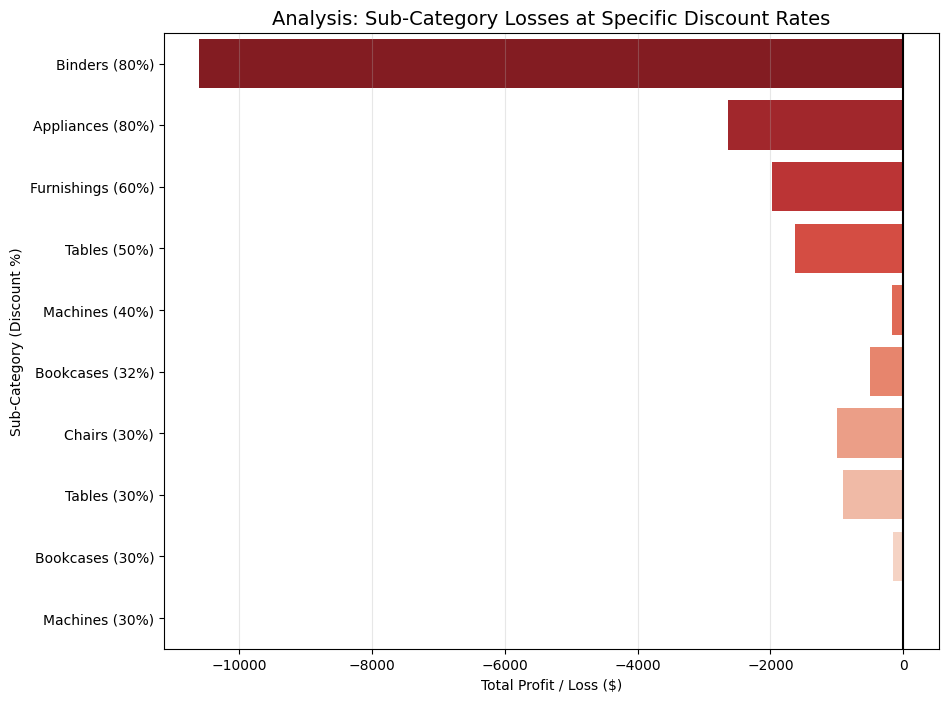

,Sub-Category,Discount,Profit,Category_Label
8,Binders,0.80,-10607.4452,Binders (80%)
4,Appliances,0.80,-2637.0186,Appliances (80%)
20,Furnishings,0.60,-1968.8777,Furnishings (60%)
36,Tables,0.50,-1627.2239,Tables (50%)
25,Machines,0.40,-169.3677,Machines (40%)
11,Bookcases,0.32,-492.2300,Bookcases (32%)
13,Chairs,0.30,-995.8903,Chairs (30%)
35,Tables,0.30,-908.6763,Tables (30%)
10,Bookcases,0.30,-154.5564,Bookcases (30%)
24,Machines,0.30,8.9994,Machines (30%)


In [38]:
# Filtering: High-Discount Transactions (30% and Above)
high_discount_df = final_dVP[final_dVP['Discount'] >= 0.3].copy()

high_discount_df_sorted = high_discount_df.sort_values(by=['Discount', 'Profit'], ascending=[False, True])

# Feature Engineering: Combining Sub-Category and Discount Levels
high_discount_df_sorted['Category_Label'] = (
    high_discount_df_sorted['Sub-Category'] + 
    " (" + (high_discount_df_sorted['Discount']*100).astype(int).astype(str) + "%)"
)

plt.figure(figsize=(10, 8))
# Hue ko nikal diya taake bars "Fixed" aur "Clean" nazar aayein
sns.barplot(x='Profit', y='Category_Label', data=high_discount_df_sorted, palette='Reds_r', hue='Category_Label', legend=False)

plt.axvline(0, color='black', lw=1.5)
plt.title('Analysis: Sub-Category Losses at Specific Discount Rates', fontsize=14)
plt.xlabel('Total Profit / Loss ($)')
plt.ylabel('Sub-Category (Discount %)')
plt.grid(axis='x',alpha=0.3)
plt.show()

high_discount_df_sorted

While a 20% discount is manageable across the board, specific sub-categories are extremely sensitive to higher discounts. For instance, Binders and Appliances at an 80% discount rate are the primary contributors to the $13,000+ loss (Binders alone accounting for -$10,607) in the Central Region. Even other sub-categories like Chairs, Tables, and Furnishings are also consistently losing money at discounts above 30%. This indicates a systemic issue in our pricing strategy for the Central Region.

### **Analysis of Profit vs. Shipping Mode**
After identifying the Central Region as a loss hotspot and discount over 80%, I investigated whether high shipping costs were the reason. 
I compared the **Quantity** sold against the **Total Profit** for each shipping mode to find the root cause.

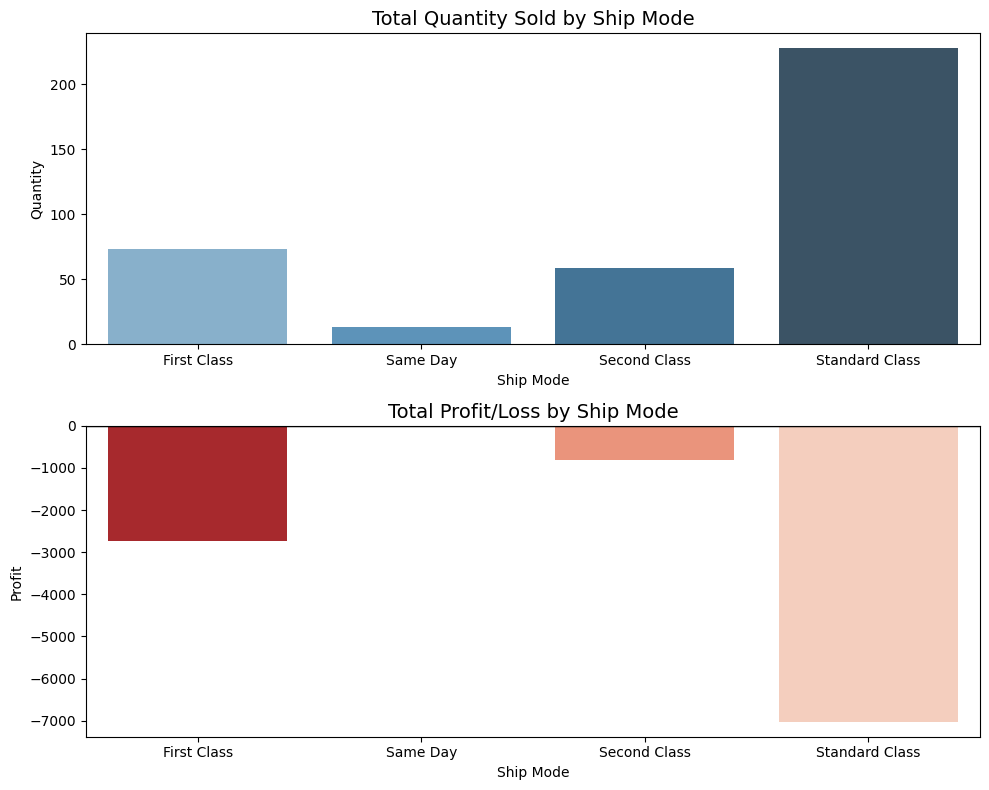

In [43]:
find_binders_Loss = df[(df['Order_year'] == 2017) & (df['Region'] == 'Central') & (df['Category'] == 'Office Supplies') & (df['Profit'] < 0) & (df['Sub-Category'] == 'Binders')]

find_loss = find_binders_Loss.groupby('Ship Mode').agg({
    'Profit': 'sum',
    'Quantity': 'sum',
    'Discount': 'mean'
}).reset_index()
find_loss

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(10, 8))

# 1. Graph: Quantity
sns.barplot(x='Ship Mode', y='Quantity', data=find_loss, ax=ax1, palette='Blues_d', hue='Ship Mode', label= False)
ax1.set_title('Total Quantity Sold by Ship Mode', fontsize=14)

# 2.Graph: Profit
sns.barplot(x='Ship Mode', y='Profit', data=find_loss, ax=ax2, palette='Reds_r', hue='Ship Mode', label= False)
ax2.set_title('Total Profit/Loss by Ship Mode', fontsize=14)
ax2.axhline(0, color='black', linewidth=1) # Zero line taake loss saaf dikhe

plt.savefig('Ship_mode_analysis.png')
plt.tight_layout()
plt.show()

**Key Observation:**
* **Standard Class** has the highest sales volume (**228 units**) but also the highest loss (**-$7,027**).
* Even the cheapest shipping mode (Standard) is deeply unprofitable. 
* **Conclusion:** The loss is not due to shipping costs, but because the **80% discount** has dropped the selling price below the basic operational cost.

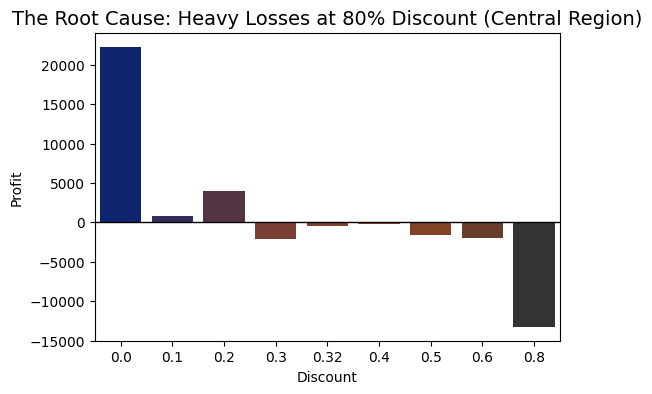

,Sub-Category,Discount,Profit
0,Accessories,0.00,2513.1481
1,Accessories,0.20,428.0834
2,Appliances,0.00,2305.1745
3,Appliances,0.10,18.4604
4,Appliances,0.80,-2637.0186
5,Art,0.00,267.7252
6,Art,0.20,230.1065
7,Binders,0.00,6650.3027
8,Binders,0.80,-10607.4452
9,Bookcases,0.00,135.7610


In [31]:
# Analysis: Central Region Performance (2017)

Discount_Profit = df[(df['Order_year'] == 2017 ) & (df['Region'] == 'Central')]

final_dVP = Discount_Profit.groupby(['Sub-Category', 'Discount'])['Profit'].sum().reset_index()
plt.figure(figsize=(6,4))
sns.barplot(x='Discount', y='Profit', data=final_dVP, estimator='sum', errorbar=None, palette='dark_d', hue='Discount', legend=False)
plt.axhline(0, color='black', linewidth=1) 
plt.title('The Root Cause: Heavy Losses at 80% Discount (Central Region)', fontsize=14)
plt.show()

final_dVP

# Deep analysis
A deep dive into the Central Region's 2017 performance reveals a critical profitability threshold upto the 20% discount level.

Safe Zone (0-20%): Discounts within this range consistently maintain positive margins.

Danger Zone (30%+): Any discount exceeding 20% acts as a direct trigger for losses.

The Root Cause: The 80% discount rate is the single most destructive factor, causing massive profit loss in the Central Region, with Binders being the primary driver of these losses(contributing over $10k in negative profit).

Recommendation: To restore regional profitability, it is imperative to eliminate the 80% discount tier and strictly cap promotional discounts at 20%.

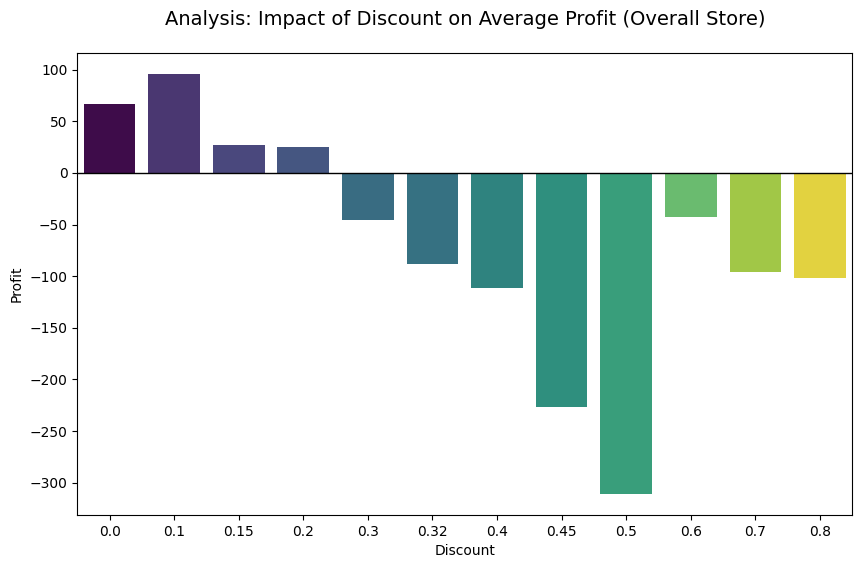

In [42]:
# Average Profit by Discount Level (Overall Dataset)
plt.figure(figsize=(10,6))
sns.barplot(x='Discount', y='Profit', data=df, estimator='mean', errorbar=None, palette='viridis', hue='Discount', legend=False)
plt.axhline(0, color='black', linewidth=1)
plt.title('Analysis: Impact of Discount on Average Profit (Overall Store)', fontsize=14, pad=20)
plt.show()

Overall trend suggests that any discount above 50% (0.5) significantly reduces the profit margin across all regions.

# Final Conclusion & Insights
Through this data-driven analysis, it is evident that while absolute profit is increasing, the overall Profit Margin is declining. This divergence is driven by a significant increase in the volume and depth of negative-profit transactions in 2017 compared to 2016. Essentially, we are processing a higher volume of loss-making orders.

Key Finding: The 80% discount level is the primary driver of regional losses, specifically within the Binders and Appliances sub-categories in the Central Region.

Data Integrity: By auditing the dataset for duplicate transactions and engineering composite labels (Sub-Category + Discount), we ensured that the insights are both accurate and granular.

Business Recommendation: To restore regional profitability, I recommend a strict cap on promotional discounts at 20% and a complete phase-out of the 80% discount tier.